<a href="https://colab.research.google.com/github/Joammp/ML_Radio_Signal/blob/main/pt_86_conv2d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#IMPORTS

In [ ]:
!pip install scikeras
!pip install tensorflow

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np # Import numpy for potential future use

from matplotlib import pyplot as plt

import h5py
import json
from numpy import argwhere

from sklearn.model_selection import train_test_split
import numpy as np

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
import threading # Usaremos threading para garantir a segurança da thread
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

import numpy as np
import tensorflow as tf
from tensorflow import keras
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam, SGD
from sklearn.model_selection import RandomizedSearchCV
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from tqdm.auto import tqdm

In [ ]:
# Before creating the plot, set the desired font size and name
plt.rcParams['font.size'] = 12  # Change the default font size
plt.rcParams['font.family'] = 'serif'  # Change the default font family (e.g., 'serif', 'sans-serif', 'monospace')

# You can also change these settings for specific text elements if needed.
# For example, to change the title font size:
# plt.title('Plot Title', fontsize=16)


#IMPORT DATASET

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pinxau1000/radioml2018")

print("Path to dataset files:", path)

h5py_path = path + '/GOLD_XYZ_OSC.0001_1024.hdf5'
modulation_classes_path = path + '/classes-fixed.json'
# Open the dataset
hdf5_file = h5py.File(h5py_path, 'r')
# Load the modulation classes. You can also copy and paste the content of classes-fixed.txt.
modulation_classes = json.load(open(modulation_classes_path, 'r'))

# Read the HDF5 groups
data = hdf5_file['X']
modulation_onehot = hdf5_file['Y']
snr = hdf5_file['Z']

Path to dataset files: /root/.cache/kagglehub/datasets/pinxau1000/radioml2018/versions/2


In [ ]:


# Load all data from the datasets in the HDF5 file
X = data
Y = modulation_onehot
Z = snr

# Convert one-hot encoded labels to numerical labels
y = np.argmax(Y, axis=1)

#DEFS


In [ ]:


def get_indices_by_snr(target_snrs):
    """
    Separates and returns indices corresponding to specified SNR values.

    Args:
        target_snrs (list or np.ndarray): A list or array of SNR values
                                          (e.g., [-20, -10, 0, 10]) to filter by.

    Returns:
        np.ndarray: A sorted numpy array of indices from the original dataset (X, Y, Z, y)
                    where the SNR matches one of the target_snrs.
    """
    # Convert target_snrs to a set for efficient lookup
    target_snrs_set = set(target_snrs)

    # Get the SNR values from the Z array (assuming Z is globally available)
    # Z[:, 0] extracts the SNR column
    all_snr_values = Z[:, 0]

    # Find indices where the SNR value is in the target_snrs_set
    matching_indices = np.where(np.isin(all_snr_values, list(target_snrs_set)))[0]

    return np.sort(matching_indices)

# Example Usage:
# Let's say you want indices for SNR values of -20dB, 0dB, and 10dB
# desired_snrs = [-20, 0, 10]
# selected_snr_indices = get_indices_by_snr(desired_snrs)
#
# print(f"Found {len(selected_snr_indices)} samples with SNR in {desired_snrs}")
#
# # You can then use these indices to access the corresponding data
# # X_filtered_by_snr = X[selected_snr_indices]
# # y_filtered_by_snr = y[selected_snr_indices]
# # Z_filtered_by_snr = Z[selected_snr_indices]

# The previous content of this cell was likely a print statement.
# I'll add a simple print to confirm the function is defined.


In [ ]:
def get_samples_by_snr(target_snrs):
    """
    Returns data samples (X, Y, Z, y) corresponding to specified SNR values.

    Args:
        target_snrs (list or np.ndarray): A list or array of SNR values
                                          (e.g., [-20, -10, 0, 10]) to filter by.

    Returns:
        tuple: A tuple containing X_filtered, Y_filtered, Z_filtered, y_filtered
               for the selected SNR values.
    """
    # Use the existing function to get indices for the target SNRs
    selected_indices = get_indices_by_snr(target_snrs)

    # Use these indices to subset the global data arrays
    X_filtered = X[selected_indices]
    Y_filtered = Y[selected_indices]
    Z_filtered = Z[selected_indices]
    y_filtered = y[selected_indices]

    print(f"\nSubset created with {len(selected_indices)} samples for SNR values: {target_snrs}.")
    print(f"Shape of X_filtered: {X_filtered.shape}")
    print(f"Shape of Y_filtered: {Y_filtered.shape}")
    print(f"Shape of Z_filtered: {Z_filtered.shape}")
    print(f"Shape of y_filtered: {y_filtered.shape}")

    return X_filtered, Y_filtered, Z_filtered, y_filtered, selected_indices

print("Function 'get_samples_by_snr' defined.")

Function 'get_samples_by_snr' defined.


In [ ]:
def subset_snr (target_snrs, frac):
    X_snr, Y_snr, Z_snr, y_snn, selected_indices = get_samples_by_snr(target_snrs)

    ind_snr_frac, ind_lixo, Y_snr_frac, Ysnr_lixo = train_test_split(
        selected_indices,
        Y_snr,
        test_size=1-frac,
        random_state=42,
        stratify=Y_snr
    )

    ind_snr_frac = np.sort(ind_snr_frac)
    X_filtered = X[ind_snr_frac]
    Y_filtered = Y[ind_snr_frac]
    Z_filtered = Z[ind_snr_frac]
    y_filtered = y[ind_snr_frac]

    print(f"\nSubset created with {len(selected_indices)} samples for SNR values: {target_snrs}.")
    print(f"Shape of X_filtered: {X_filtered.shape}")
    print(f"Shape of Y_filtered: {Y_filtered.shape}")
    print(f"Shape of Z_filtered: {Z_filtered.shape}")
    print(f"Shape of y_filtered: {y_filtered.shape}")

    return X_filtered, Y_filtered, Z_filtered, y_filtered, ind_snr_frac





In [ ]:
def split (indices, lables):
  train_val_indices, test_indices, train_val_lables, test_lables = train_test_split(
        indices,
        lables,
        test_size=0.2,
        random_state=42,
        stratify=lables
    )

  train_indices, val_indices, train_lables, val_lables = train_test_split(
        train_val_indices,
        train_val_lables,
        test_size=0.25,
        random_state=42,
        stratify=train_val_lables
    )

  train_indices_sorted = np.sort(train_indices)
  val_indices_sorted = np.sort(val_indices)
  test_indices_sorted = np.sort(test_indices)

  return train_indices_sorted, val_indices_sorted, test_indices_sorted

#SUBSET

In [ ]:
# Exemplo: Obter amostras com SNR de 0dB, 10dB e 20dB
desired_snrs_example = [20, 30]
# desired_snrs_example= [-20, -18,-16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 20, 22, 24, 26, 28, 30]
X_subset, Y_subset, Z_subset, y_subset, selected_indices = subset_snr(desired_snrs_example,0.99)

print(f"\nPrimeiras 5 classes (y) dos dados filtrados:\n{y_subset[1500]}")
print(f"Primeiros 5 valores de SNR (Z) dos dados filtrados:\n{Z_subset[:5]}")


Subset created with 196608 samples for SNR values: [20, 30].
Shape of X_filtered: (196608, 1024, 2)
Shape of Y_filtered: (196608, 24)
Shape of Z_filtered: (196608, 1)
Shape of y_filtered: (196608,)

Subset created with 196608 samples for SNR values: [20, 30].
Shape of X_filtered: (194641, 1024, 2)
Shape of Y_filtered: (194641, 24)
Shape of Z_filtered: (194641, 1)
Shape of y_filtered: (194641,)

Primeiras 5 classes (y) dos dados filtrados:
0
Primeiros 5 valores de SNR (Z) dos dados filtrados:
[[20]
 [20]
 [20]
 [20]
 [20]]


In [ ]:
indices = selected_indices#_sorted
lables = y_subset
train_indices_sorted, val_indices_sorted, test_indices_sorted = split(indices, lables)

In [ ]:
X_train = X[train_indices_sorted]
X_val = X[val_indices_sorted]
X_test = X[test_indices_sorted]

y_train = y[train_indices_sorted]
y_val = y[val_indices_sorted]
y_test = y[test_indices_sorted]

In [ ]:
X_train_reshaped = X_train.reshape(X_train.shape[0], -1)
X_val_reshaped = X_val.reshape(X_val.shape[0], -1)
X_test_reshaped = X_test.reshape(X_test.shape[0], -1)

print(f"Shape of X_train after reshaping: {X_train_reshaped.shape}")
print(f"Shape of X_val after reshaping: {X_val_reshaped.shape}")
print(f"Shape of X_test after reshaping: {X_test_reshaped.shape}")

Shape of X_train after reshaping: (116784, 2048)
Shape of X_val after reshaping: (38928, 2048)
Shape of X_test after reshaping: (38929, 2048)


#SET TOTAL

In [ ]:
num_samples = X.shape[0]
indices = np.arange(num_samples) #selected_indices_sorted
lables = np.column_stack((y, Z))

train_indices_sorted, val_indices_sorted, test_indices_sorted = split(indices, lables)

#CNN PT

In [ ]:
class H5PyDataset(Dataset):
    def __init__(self, h5_filepath, data_X_name, data_Y_name, data_Z_name, indices, formats):
        self.h5_filepath = h5_filepath
        self.data_X_name = data_X_name
        self.data_Y_name = data_Y_name
        self.indices = np.array(indices)
        self.formats = formats
        self.file = None

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        # Abre o arquivo apenas uma vez por worker
        if self.file is None:
            self.file = h5py.File(self.h5_filepath, 'r')
            self.X_data = self.file[self.data_X_name]
            self.Y_data = self.file[self.data_Y_name]

        # Pega o índice real baseado na sua lista de sorteados
        real_idx = self.indices[idx]

        # Busca UMA amostra (1024, 2)
        x = self.X_data[real_idx, :]
        y = self.Y_data[real_idx]

        # Normalização Individual (Essencial para sinais)
        mean = x.mean()
        std = x.std()
        x = (x - mean) / (std + 1e-8)

        # Trata o Label
        if self.formats == 0:
            # Se y for um vetor (One-Hot), pega o índice da classe
            if hasattr(y, "__len__"):
                y = np.argmax(y)

        # Conversão para Tensor
        x_tensor = torch.from_numpy(x).float() # [1024, 2]
        x_tensor = x_tensor.permute(1, 0)      # [2, 1024] (Canais primeiro)
        y_tensor = torch.tensor(y).long()      # Valor escalar

        return x_tensor, y_tensor

In [ ]:
from torch.utils.data import DataLoader, BatchSampler, RandomSampler, SequentialSampler

# 1. Dataset (Certifique-se que o __getitem__ aceita a lista de índices como discutimos)
# Dataset de Treino
train_dataset = H5PyDataset(
    h5_filepath=h5py_path,
    data_X_name='X',
    data_Y_name='Y',
    data_Z_name='Z',
    indices=train_indices_sorted,  # Seus índices de treino
    formats=0
)

# Dataset de Validação
val_dataset = H5PyDataset(
    h5_filepath=h5py_path,
    data_X_name='X',
    data_Y_name='Y',
    data_Z_name='Z',
    indices=val_indices_sorted,    # Seus índices de validação
    formats=0
)

test_dataset = H5PyDataset(
    h5_filepath=h5py_path,
    data_X_name='X',
    data_Y_name='Y',
    data_Z_name='Z',
    indices=test_indices_sorted,    # Seus índices de validação
    formats=0
)

batch_size = 64

# Remova o BatchSampler e o collate_fn.
# Use shuffle=True para o treino e shuffle=False para validação.
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,          # Isso substitui o RandomSampler
    drop_last=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,         # Isso substitui o SequentialSampler
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,         # Isso substitui o SequentialSampler
    drop_last=False
)

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv1d(2, 64, kernel_size=11, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=7, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(128, 256, kernel_size=5, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(512, 1024, kernel_size=3, padding=1),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        # Técnica para detectar o tamanho do flatten automaticamente:
        self.flatten = nn.Flatten()
        with torch.no_grad():
            # Passamos um dado "dummy" de teste para ver o que sai das convs
            dummy_input = torch.zeros(1, 2, 1024)
            dummy_output = self.features(dummy_input)
            self.n_flatten = dummy_output.view(1, -1).size(1)

        print(f"Tamanho detectado para o Flatten: {self.n_flatten}")

        self.classifier = nn.Sequential(
            nn.Linear(self.n_flatten, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        x = self.classifier(x)
        return x

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(2, 64, kernel_size=(1, 11), padding=(0, 3)),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(1, 2)),

            nn.Conv2d(64, 128, kernel_size=(1, 7), padding=(0, 2)),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(1, 2)),

            nn.Conv2d(128, 256, kernel_size=(1, 5), padding=(0, 1)),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(1, 2)),

            nn.Conv2d(256, 512, kernel_size=(1, 3), padding=(0, 1)),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(1, 2)),

            nn.Conv2d(512, 1024, kernel_size=(1, 3), padding=(0, 1)),
            nn.BatchNorm2d(1024),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(1, 2))
        )

        self.flatten = nn.Flatten()
        with torch.no_grad():
            # Input agora é 4D: (batch, channels, height=1, width=L)
            dummy_input = torch.zeros(1, 2, 1, 1024)
            dummy_output = self.features(dummy_input)
            self.n_flatten = dummy_output.view(1, -1).size(1)

        print(f"Tamanho detectado para o Flatten: {self.n_flatten}")

        self.classifier = nn.Sequential(
            nn.Linear(self.n_flatten, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # Adiciona dimensão de altura: [B, C, L] -> [B, C, 1, L]
        x = x.unsqueeze(2)
        x = self.features(x)
        x = self.flatten(x)
        x = self.classifier(x)
        return x

In [ ]:
def train_and_validate(model, train_loader, val_loader, criterion, optimizer, scheduler=None, epochs=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    for epoch in range(epochs):
        # --- TREINO ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        pbar_train = tqdm(train_loader, desc=f"Época {epoch+1}/{epochs} [Treino]")

        for inputs, labels in pbar_train:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        # --- VALIDAÇÃO ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        # --- CÁLCULO DAS MÉTRICAS (AQUI É O SEGREDO) ---
        final_train_loss = train_loss / len(train_loader)
        final_train_acc = 100. * train_correct / train_total
        final_val_loss = val_loss / len(val_loader)
        final_val_acc = 100. * val_correct / val_total

        # --- AGORA SIM, ATUALIZA O SCHEDULER ---
        if scheduler is not None:
            # Se for ReduceLROnPlateau, ele precisa do loss de validação
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(final_val_loss)
            else:
                scheduler.step()

        print(f"\nÉpoca {epoch+1}: Train Loss: {final_train_loss:.4f} | Val Loss: {final_val_loss:.4f} | Val Acc: {final_val_acc:.2f}%")

In [ ]:
model = CNN(num_classes=24)

Tamanho detectado para o Flatten: 31744


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

In [ ]:
# 1. Reinstancie o modelo com a nova definição da classe


# 2. Mande o modelo para a GPU (se disponível)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 3. RE-CRIE o otimizador (importante: ele precisa dos parâmetros do NOVO model)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [ ]:

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,      # divide LR por 2 quando estagna
    patience=5,      # espera 5 épocas sem melhora
    min_lr=1e-6
)

train_and_validate(model, train_loader, val_loader, criterion,
                   optimizer, scheduler=scheduler, epochs=120)

Época 1/120 [Treino]:   0%|          | 0/1825 [00:00<?, ?it/s]


Época 1: Train Loss: 1.6221 | Val Loss: 1.1779 | Val Acc: 48.01%


Época 2/120 [Treino]:   0%|          | 0/1825 [00:00<?, ?it/s]


Época 2: Train Loss: 1.3516 | Val Loss: 1.1818 | Val Acc: 46.90%


Época 3/120 [Treino]:   0%|          | 0/1825 [00:00<?, ?it/s]

...


Época 87: Train Loss: 0.1526 | Val Loss: 0.5027 | Val Acc: 86.63%


Época 88/120 [Treino]:   0%|          | 0/1825 [00:00<?, ?it/s]


Época 88: Train Loss: 0.1542 | Val Loss: 0.5092 | Val Acc: 86.59%


Época 89/120 [Treino]:   0%|          | 0/1825 [00:00<?, ?it/s]

KeyboardInterrupt: 

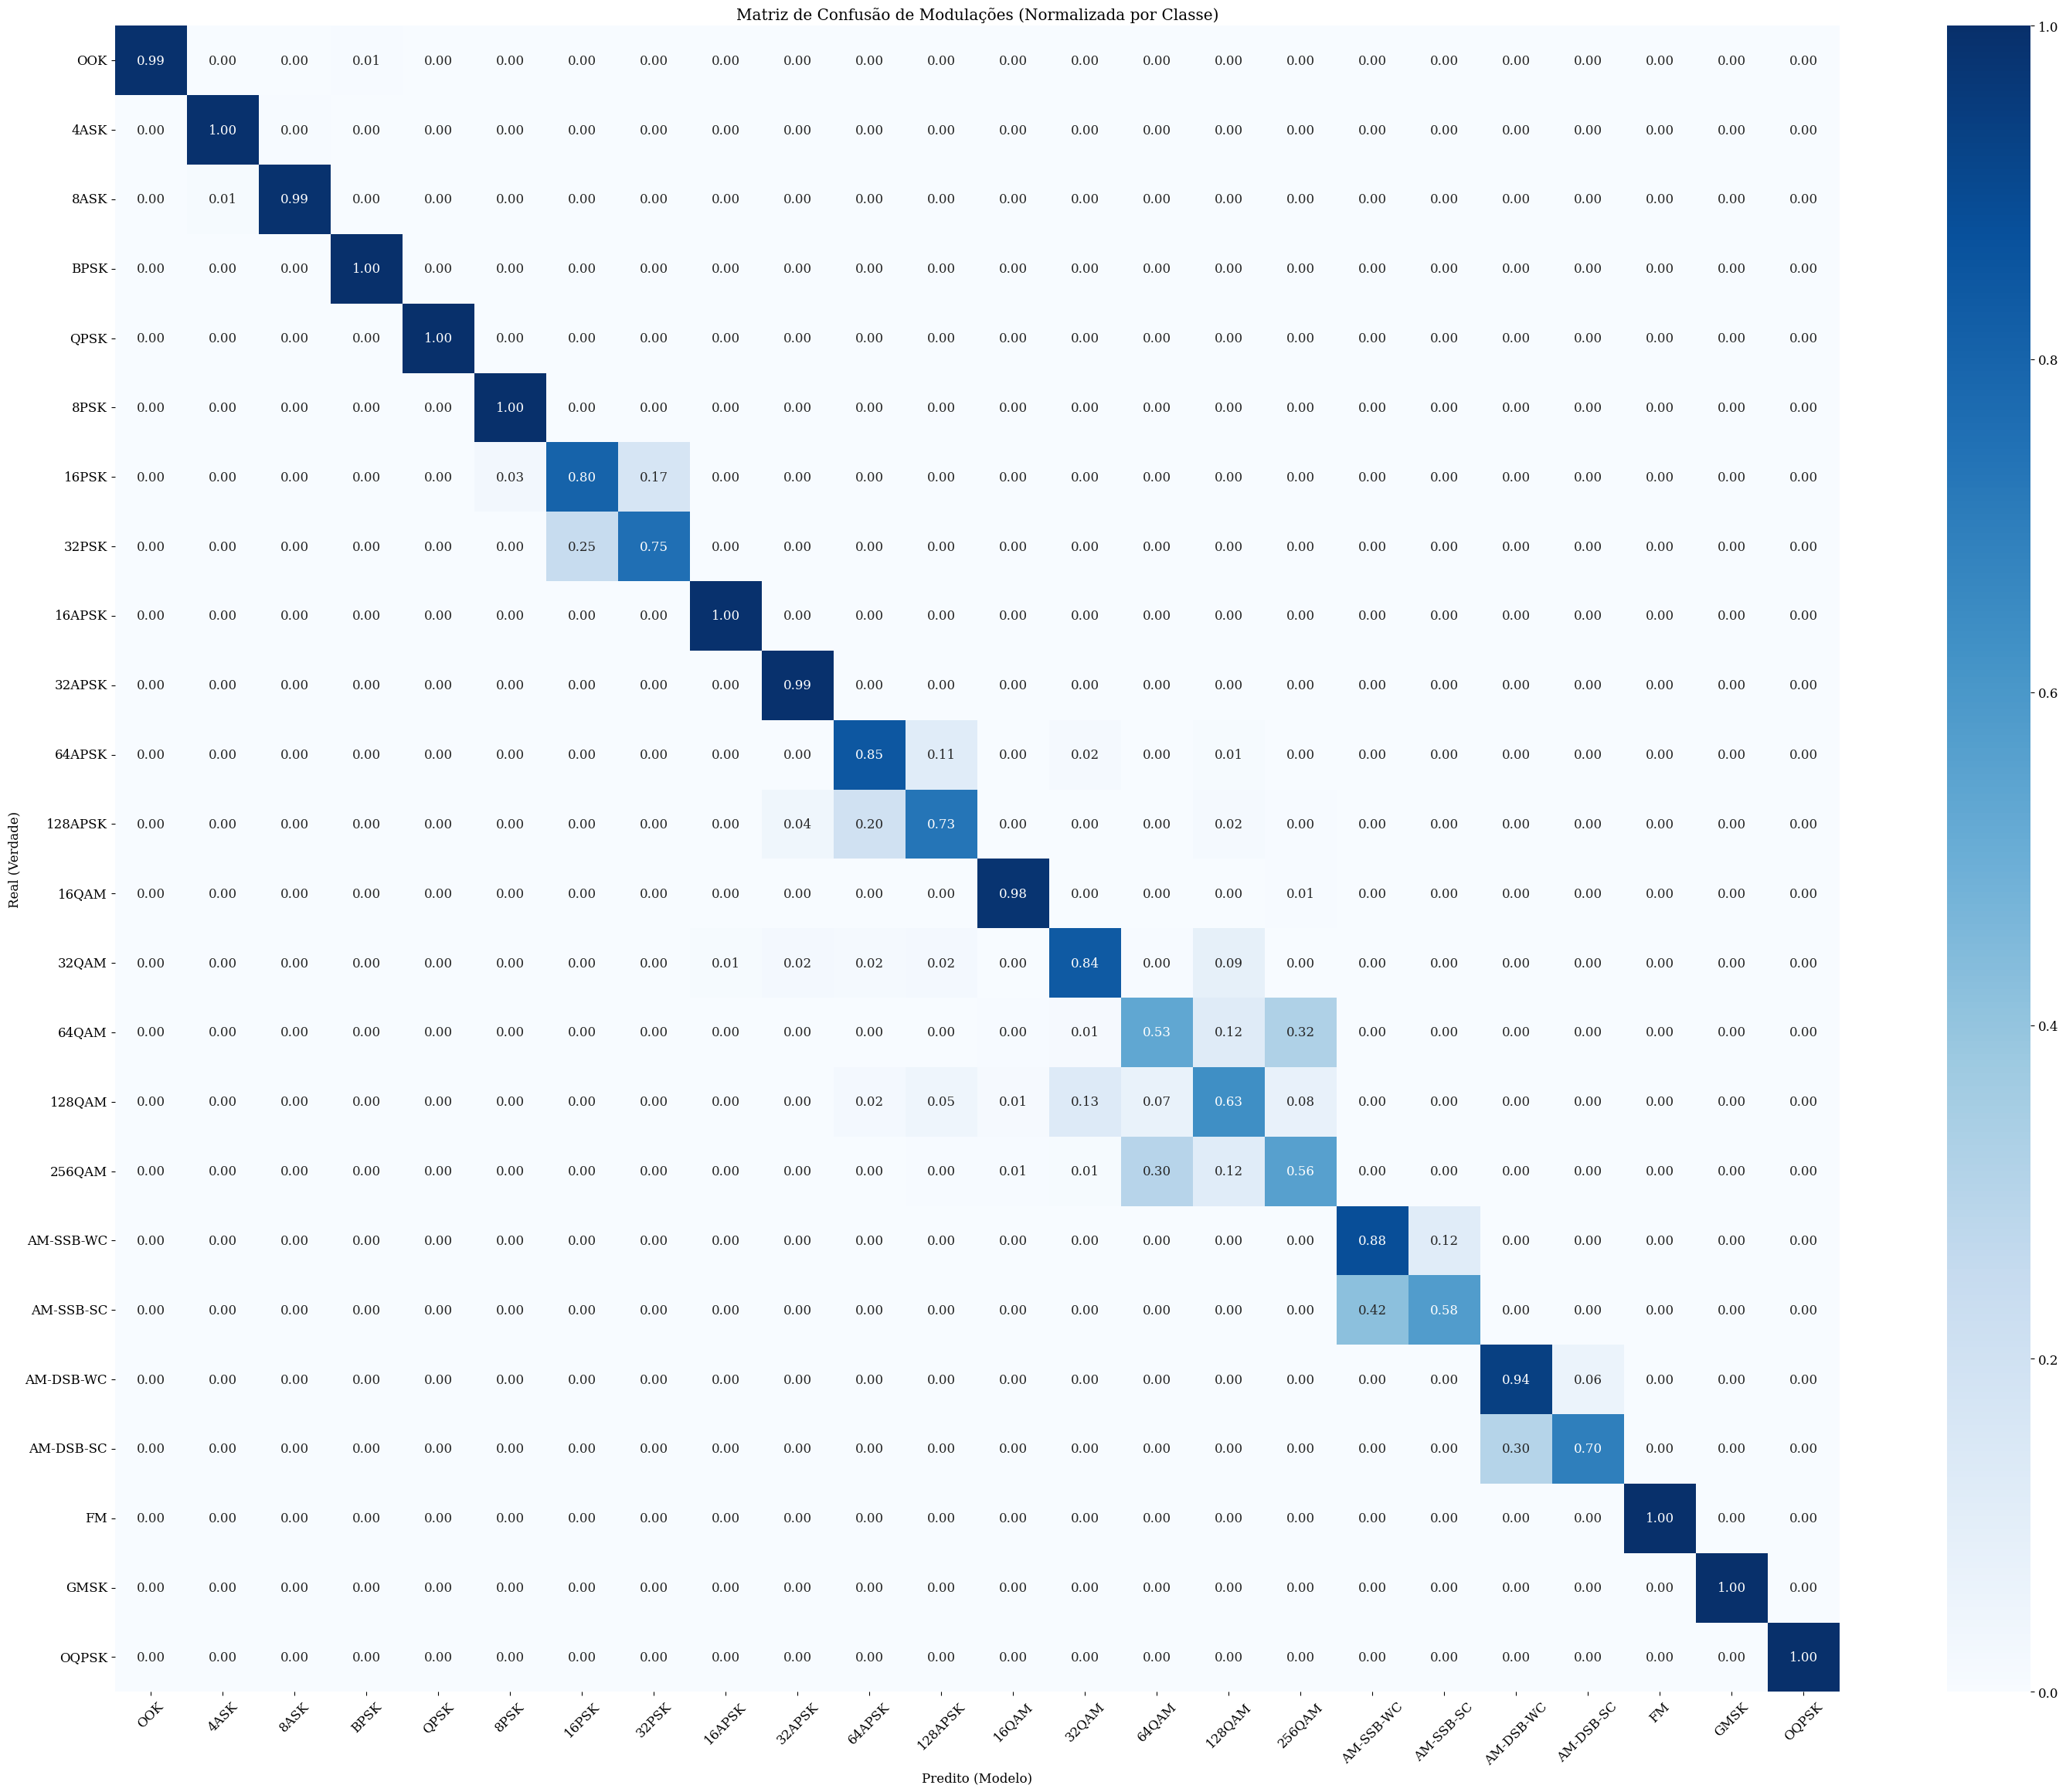

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import torch

def plot_custom_confusion_matrix(model, val_loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            # O label pode vir com dimensão extra [64, 1], corrigimos se necessário
            labels = labels.squeeze()

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Gera a matriz de confusão
    cm = confusion_matrix(all_labels, all_preds)

    # Normalização por linha (porcentagem de acerto por classe real)
    cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-8)

    plt.figure(figsize=(36, 28))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)

    plt.title('Matriz de Confusão de Modulações (Normalizada por Classe)')
    plt.xlabel('Predito (Modelo)')
    plt.ylabel('Real (Verdade)')
    plt.xticks(rotation=45)
    plt.show()

# Lista baseada na sua tabela "Fixed"
classes_fixed = [
    'OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK',
    '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '64QAM',
    '128QAM', '256QAM', 'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC', 'AM-DSB-SC',
    'FM', 'GMSK', 'OQPSK'
]

# Executar
plot_custom_confusion_matrix(model, test_loader, device, classes_fixed)